In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('retail_sales.csv')

In [3]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 100.2 KB


In [5]:
# Convert Date to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Create helper columns for time-series analysis
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month_name()

# Inspect summary statistics for numerical columns
df.describe()

,Transaction ID,Date,Age,Quantity,Price per Unit,Total Amount,Year
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-07-03 00:25:55.200000,41.39200,2.514000,179.890000,456.000000,2023.002000
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000,2023.000000
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000,2023.000000
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000,2023.000000
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000,2023.000000
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000,2024.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632,0.044699


In [6]:
print(df['Product Category'].value_counts())
print(df['Gender'].value_counts())

Product Category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64
Gender
Female    510
Male      490
Name: count, dtype: int64


In [7]:
category_summary = df.groupby('Product Category').agg(
    Total_Revenue=('Total Amount', 'sum'),
    Average_Spend=('Total Amount', 'mean'),
    Total_Units=('Quantity', 'sum')
).reset_index()

category_summary['Total_Revenue'] = category_summary['Total_Revenue'].round(2)
category_summary['Average_Spend'] = category_summary['Average_Spend'].round(2)

print(category_summary.sort_values(by='Total_Revenue', ascending=False))

  Product Category  Total_Revenue  Average_Spend  Total_Units
2      Electronics         156905         458.79          849
1         Clothing         155580         443.25          894
0           Beauty         143515         467.48          771


In [8]:
gender_category = pd.crosstab(
    df['Product Category'], 
    df['Gender'], 
    values=df['Total Amount'], 
    aggfunc='sum'
).round(2)

print("Total Revenue by Category and Gender:")
print(gender_category)

Total Revenue by Category and Gender:
Gender            Female   Male
Product Category               
Beauty             74830  68685
Clothing           81275  74305
Electronics        76735  80170


In [9]:
# Convert Date to datetime if not already done
df['Date'] = pd.to_datetime(df['Date'])

# Create a Year-Month period column for chronological grouping
df['YearMonth'] = df['Date'].dt.to_period('M')

# Group by Month and calculate total sales
monthly_sales = df.groupby('YearMonth')['Total Amount'].sum().reset_index()
monthly_sales['YearMonth'] = monthly_sales['YearMonth'].astype(str)

print("Monthly Sales Performance:")
print(monthly_sales)

Monthly Sales Performance:
   YearMonth  Total Amount
0    2023-01         35450
1    2023-02         44060
2    2023-03         28990
3    2023-04         33870
4    2023-05         53150
5    2023-06         36715
6    2023-07         35465
7    2023-08         36960
8    2023-09         23620
9    2023-10         46580
10   2023-11         34920
11   2023-12         44690
12   2024-01          1530


In [10]:
# Create age brackets
bins = [17, 25, 35, 50, 100]
labels = ['18-25', '26-35', '36-50', '50+']
df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

# Aggregate revenue and count by age group
age_summary = df.groupby('Age Group', observed=True).agg(
    Total_Revenue=('Total Amount', 'sum'),
    Transactions=('Transaction ID', 'count'),
    Avg_Spend=('Total Amount', 'mean')
).reset_index()

age_summary['Avg_Spend'] = age_summary['Avg_Spend'].round(2)
print("Performance by Age Group:")
print(age_summary)

Performance by Age Group:
  Age Group  Total_Revenue  Transactions  Avg_Spend
0     18-25          84550           169     500.30
1     26-35          98480           205     480.39
2     36-50         139660           313     446.20
3       50+         133310           313     425.91


C:\Users\Aadmin\AppData\Local\Temp\ipykernel_10856\1398558308.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_summary, x='Product Category', y='Total_Revenue', ax=axes[0, 0], palette='Blues_d')
C:\Users\Aadmin\AppData\Local\Temp\ipykernel_10856\1398558308.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=age_summary, x='Age Group', y='Total_Revenue', ax=axes[1, 1], palette='Purples_d')


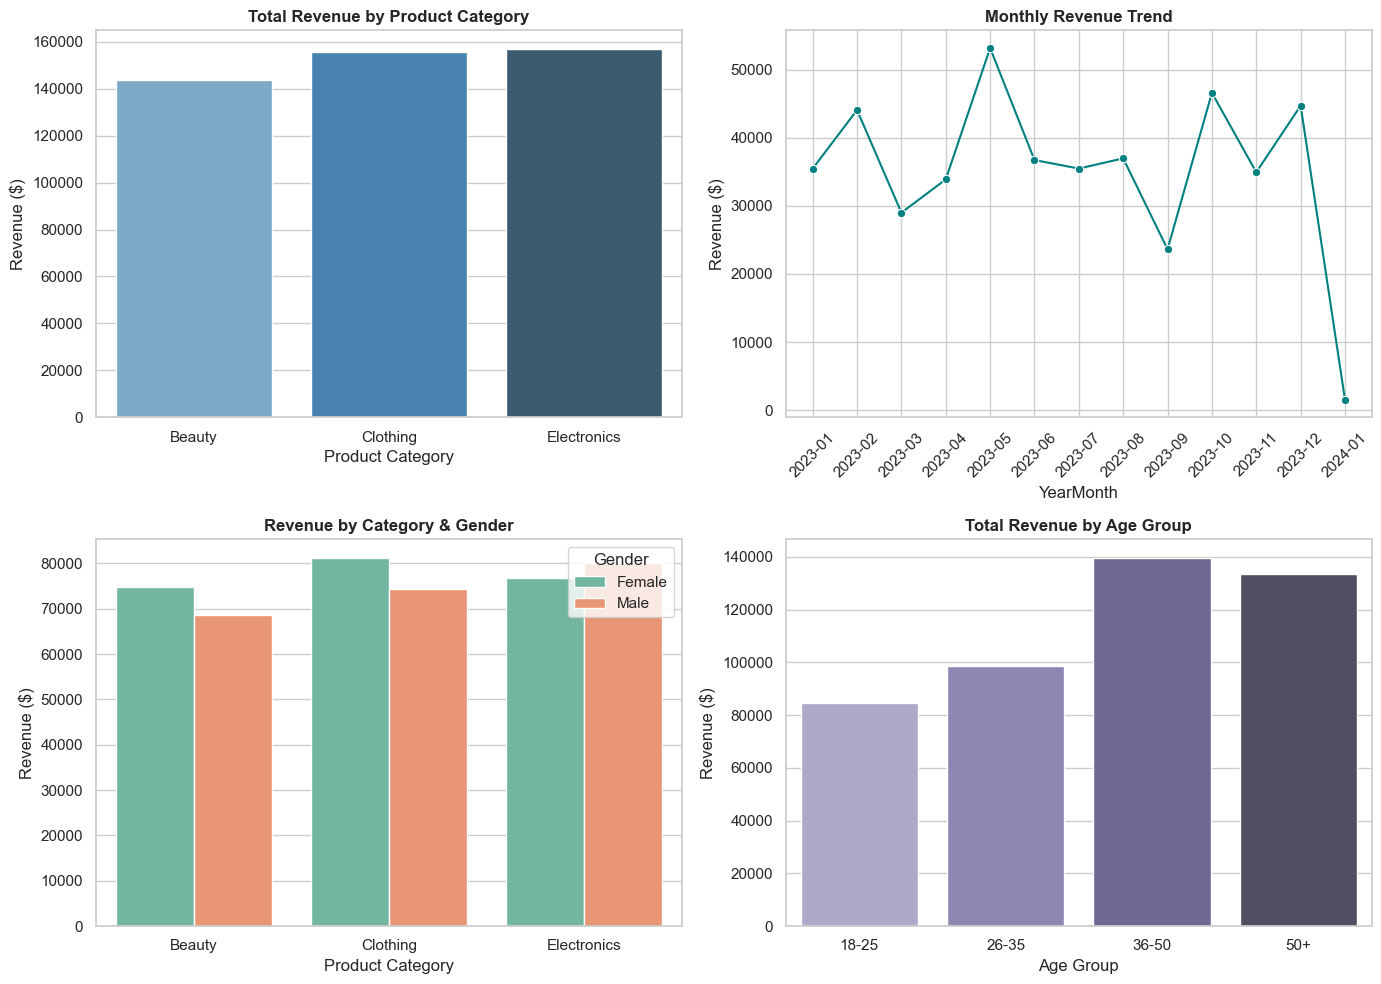

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Revenue by Product Category
sns.barplot(data=category_summary, x='Product Category', y='Total_Revenue', ax=axes[0, 0], palette='Blues_d')
axes[0, 0].set_title('Total Revenue by Product Category', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Revenue ($)')

# 2. Monthly Revenue Trend
sns.lineplot(data=monthly_sales, x='YearMonth', y='Total Amount', marker='o', ax=axes[0, 1], color='teal')
axes[0, 1].set_title('Monthly Revenue Trend', fontsize=12, fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].set_ylabel('Revenue ($)')

# 3. Category Revenue by Gender
gender_unpivoted = df.groupby(['Product Category', 'Gender'])['Total Amount'].sum().reset_index()
sns.barplot(data=gender_unpivoted, x='Product Category', y='Total Amount', hue='Gender', ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Revenue by Category & Gender', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Revenue ($)')

# 4. Total Revenue by Age Group
sns.barplot(data=age_summary, x='Age Group', y='Total_Revenue', ax=axes[1, 1], palette='Purples_d')
axes[1, 1].set_title('Total Revenue by Age Group', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Revenue ($)')

plt.tight_layout()
plt.show()